# EDA Experimental Data
Clean starter notebook for exploratory analysis of the experimental dataset.


## 1) Setup
Run this first.


In [1]:
from importlib import reload
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np

try:
    import Experimental_Data.analyze_experimental_data as analysis
except ModuleNotFoundError as exc:
    if getattr(exc, 'name', '') != 'Experimental_Data':
        raise
    current_dir = Path('Experimental_Data').resolve()
    if str(current_dir) not in sys.path:
        sys.path.insert(0, str(current_dir))
    import analyze_experimental_data as analysis

analysis = reload(analysis)

## 2) Sanity Checks (Optional)
Use this to validate sampling and NaN patterns before analysis.


In [2]:
# Input sanity checks (run before Data prep)
RUN_SANITY_CHECKS = True
SANITY_SAMPLING_RTOL = 1e-3
SANITY_SAMPLING_ATOL = 1e-9
SANITY_MAX_PRINT_PER_COLUMN = 20


def _sampling_sanity(time_values, *, rtol, atol):
    t = np.asarray(time_values, dtype=float).reshape(-1)
    finite_mask = np.isfinite(t)
    time_nonfinite = int(np.count_nonzero(~finite_mask))
    t_finite = t[finite_mask]
    if t_finite.size < 2:
        return {
            'time_nonfinite': time_nonfinite,
            'monotonic_time': False,
            'constant_sampling': False,
            'dt_median': np.nan,
            'max_rel_dt_dev': np.nan,
        }

    diffs = np.diff(t_finite)
    monotonic_time = bool(np.all(diffs > 0.0))
    positive_diffs = diffs[(np.isfinite(diffs)) & (diffs > 0.0)]
    if positive_diffs.size == 0:
        return {
            'time_nonfinite': time_nonfinite,
            'monotonic_time': monotonic_time,
            'constant_sampling': False,
            'dt_median': np.nan,
            'max_rel_dt_dev': np.nan,
        }

    dt_median = float(np.median(positive_diffs))
    abs_dev = np.abs(positive_diffs - dt_median)
    rel_dev = abs_dev / max(abs(dt_median), 1e-15)
    return {
        'time_nonfinite': time_nonfinite,
        'monotonic_time': monotonic_time,
        'constant_sampling': bool(np.all(np.isclose(positive_diffs, dt_median, rtol=rtol, atol=atol))),
        'dt_median': dt_median,
        'max_rel_dt_dev': float(np.max(rel_dev)),
    }


def _column_label(col_idx, channel_names):
    if channel_names is not None and 0 <= int(col_idx) < len(channel_names):
        name = str(channel_names[int(col_idx)]).strip()
        if name:
            return f"col {int(col_idx)} ({name})"
    return f"col {int(col_idx)}"


def _nan_column_time_report(data, time_values, channel_names, *, max_items=20):
    arr = np.asarray(data, dtype=float)
    if arr.ndim != 2:
        return []

    t = np.asarray(time_values, dtype=float).reshape(-1)
    have_time = t.size == arr.shape[0]
    lines = []

    for col_idx in range(arr.shape[1]):
        col = np.asarray(arr[:, col_idx], dtype=float)
        nan_idx = np.flatnonzero(np.isnan(col))
        if nan_idx.size == 0:
            continue

        shown = nan_idx[: int(max_items)]
        samples = []
        for idx in shown:
            i = int(idx)
            if have_time:
                t_i = t[i]
                if np.isfinite(t_i):
                    samples.append(f"(i={i}, t={float(t_i):.6g})")
                else:
                    samples.append(f"(i={i}, t=nonfinite)")
            else:
                samples.append(f"(i={i})")

        extra = ""
        if nan_idx.size > int(max_items):
            extra = f" ... +{int(nan_idx.size - int(max_items))} more"

        lines.append(
            f"{_column_label(col_idx, channel_names)}: nan_count={int(nan_idx.size)} at "
            + ", ".join(samples)
            + extra
        )

    return lines


if RUN_SANITY_CHECKS:
    mat_files = analysis._resolve_mat_files()
    print(
        f"Sanity checks (sampling rtol={SANITY_SAMPLING_RTOL:g}, atol={SANITY_SAMPLING_ATOL:g})"
    )
    all_ok = True
    for mat_file in mat_files:
        try:
            data, channel_names = analysis._load_data_matrix(mat_file, analysis.DATA_VARIABLE)
        except Exception as exc:
            all_ok = False
            print(f"[FAIL] {mat_file.name}: could not load file ({exc})")
            continue

        total_count = int(data.size)
        matrix_nonfinite = int(total_count - np.count_nonzero(np.isfinite(data)))
        time_raw = analysis._select_column(data, channel_names, ['time', 'Time'], 0, role='sanity-check time')
        sampling = _sampling_sanity(
            time_raw,
            rtol=float(SANITY_SAMPLING_RTOL),
            atol=float(SANITY_SAMPLING_ATOL),
        )

        ok = (
            matrix_nonfinite == 0
            and int(sampling['time_nonfinite']) == 0
            and bool(sampling['monotonic_time'])
            and bool(sampling['constant_sampling'])
        )
        status = 'OK' if ok else 'WARN'
        if not ok:
            all_ok = False

        dt_median = sampling['dt_median']
        max_rel_dt_dev = sampling['max_rel_dt_dev']
        dt_txt = f"{dt_median:.9g}" if np.isfinite(dt_median) else 'n/a'
        max_rel_txt = f"{max_rel_dt_dev:.3e}" if np.isfinite(max_rel_dt_dev) else 'n/a'
        print(
            f"[{status}] {mat_file.name}: matrix_nonfinite={matrix_nonfinite}/{total_count}, "
            f"time_nonfinite={int(sampling['time_nonfinite'])}, "
            f"monotonic_time={bool(sampling['monotonic_time'])}, "
            f"constant_sampling={bool(sampling['constant_sampling'])}, "
            f"dt_median={dt_txt}, max_rel_dt_dev={max_rel_txt}"
        )

        nan_lines = _nan_column_time_report(
            data,
            time_raw,
            channel_names,
            max_items=int(SANITY_MAX_PRINT_PER_COLUMN),
        )
        if nan_lines:
            print(f"  NaN details (showing up to {int(SANITY_MAX_PRINT_PER_COLUMN)} rows per column):")
            for line in nan_lines:
                print(f"    {line}")

    if all_ok:
        print('Sanity checks passed for all selected files.')
    else:
        print('Sanity checks found issues in one or more files. Continuing.')



Sanity checks (sampling rtol=0.001, atol=1e-09)
[OK] test3003.mat: matrix_nonfinite=0/5806718, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3004.mat: matrix_nonfinite=0/8690734, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3005.mat: matrix_nonfinite=0/7081470, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3006.mat: matrix_nonfinite=0/11953192, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3008.mat: matrix_nonfinite=0/6033636, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3010_part1.mat: matrix_nonfinite=0/5616500, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3010_part2.mat: matrix_n

## 3) Data Prep
Loads selected files into `entries` for downstream plotting.


In [3]:
# Data prep
PRINT_SUMMARY = True
mat_files = analysis._resolve_mat_files()
entries = [analysis._process_file(p) for p in mat_files]
colors = plt.cm.tab10(np.linspace(0.0, 1.0, max(len(entries), 2)))
n_rows = len(entries)

if PRINT_SUMMARY:
    for entry in entries:
        s = entry['summary']
        print(
            f"{entry['label']}: Umean={s['umean']:.6f} m/s, Ur={s['ur']:.6f}, "
            f"Cd={s['cd']:.6f}, Ydomfreq={s['ydomfreq']:.6f} +/- {s['ydomfreq_std']:.6f} Hz, "
            f"nt={s['nt']}, dt={s['dt']:.6f} s, Fs={s['fs']:.6f} Hz, "
            f"coeff_norm={s['coeff_norm_mode']}"
        )
        if analysis.REMOVE_INERTIA_FROM_CF:
            print(
                f"{entry['label']}: applied inertia removal with "
                f"m_remove={s['m_inertia_removed']:.6f} kg "
                f"(M={analysis.M:.6f} kg, m_a={s['m_added']:.6f} kg, "
                f"include_m_a={analysis.INERTIA_INCLUDE_ADDED_MASS})"
            )

print(f'Loaded {len(entries)} entries from {len(mat_files)} file(s).')

test3003: Umean=0.328361 m/s, Ur=2.934414, Cd=1.307223, Ydomfreq=0.616321 +/- 0.116284 Hz, nt=126233, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=mean_u_plus_dy2
test3003: applied inertia removal with m_remove=16.790000 kg (M=16.790000 kg, m_a=8.050331 kg, include_m_a=False)
test3004: Umean=0.455822 m/s, Ur=4.073474, Cd=1.780194, Ydomfreq=0.771718 +/- 0.076332 Hz, nt=188929, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=mean_u_plus_dy2
test3004: applied inertia removal with m_remove=16.790000 kg (M=16.790000 kg, m_a=8.050331 kg, include_m_a=False)
test3005: Umean=0.647159 m/s, Ur=5.783371, Cd=2.418696, Ydomfreq=1.135470 +/- 0.050744 Hz, nt=153945, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=mean_u_plus_dy2
test3005: applied inertia removal with m_remove=16.790000 kg (M=16.790000 kg, m_a=8.050331 kg, include_m_a=False)
test3006: Umean=0.857951 m/s, Ur=7.667119, Cd=2.154798, Ydomfreq=1.588597 +/- 0.127398 Hz, nt=259852, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=mean_u_plus_dy2
test3006: 

## 4) Key Timeseries + End Histograms
Plots reduced velocity `U_r`, spring-force signal `Fy2-Fy1`, and displacement with a rotated histogram panel at the end of each timeseries.


/var/folders/45/0414q_nx25dcwfzhlc7w0gd80000gn/T/ipykernel_14705/397598628.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_ts.tight_layout()


Saved figure to /Users/kasperslagstad/Desktop/Master-Thesis/Images/EDA/ExperimentalData/timeseries_raw.png


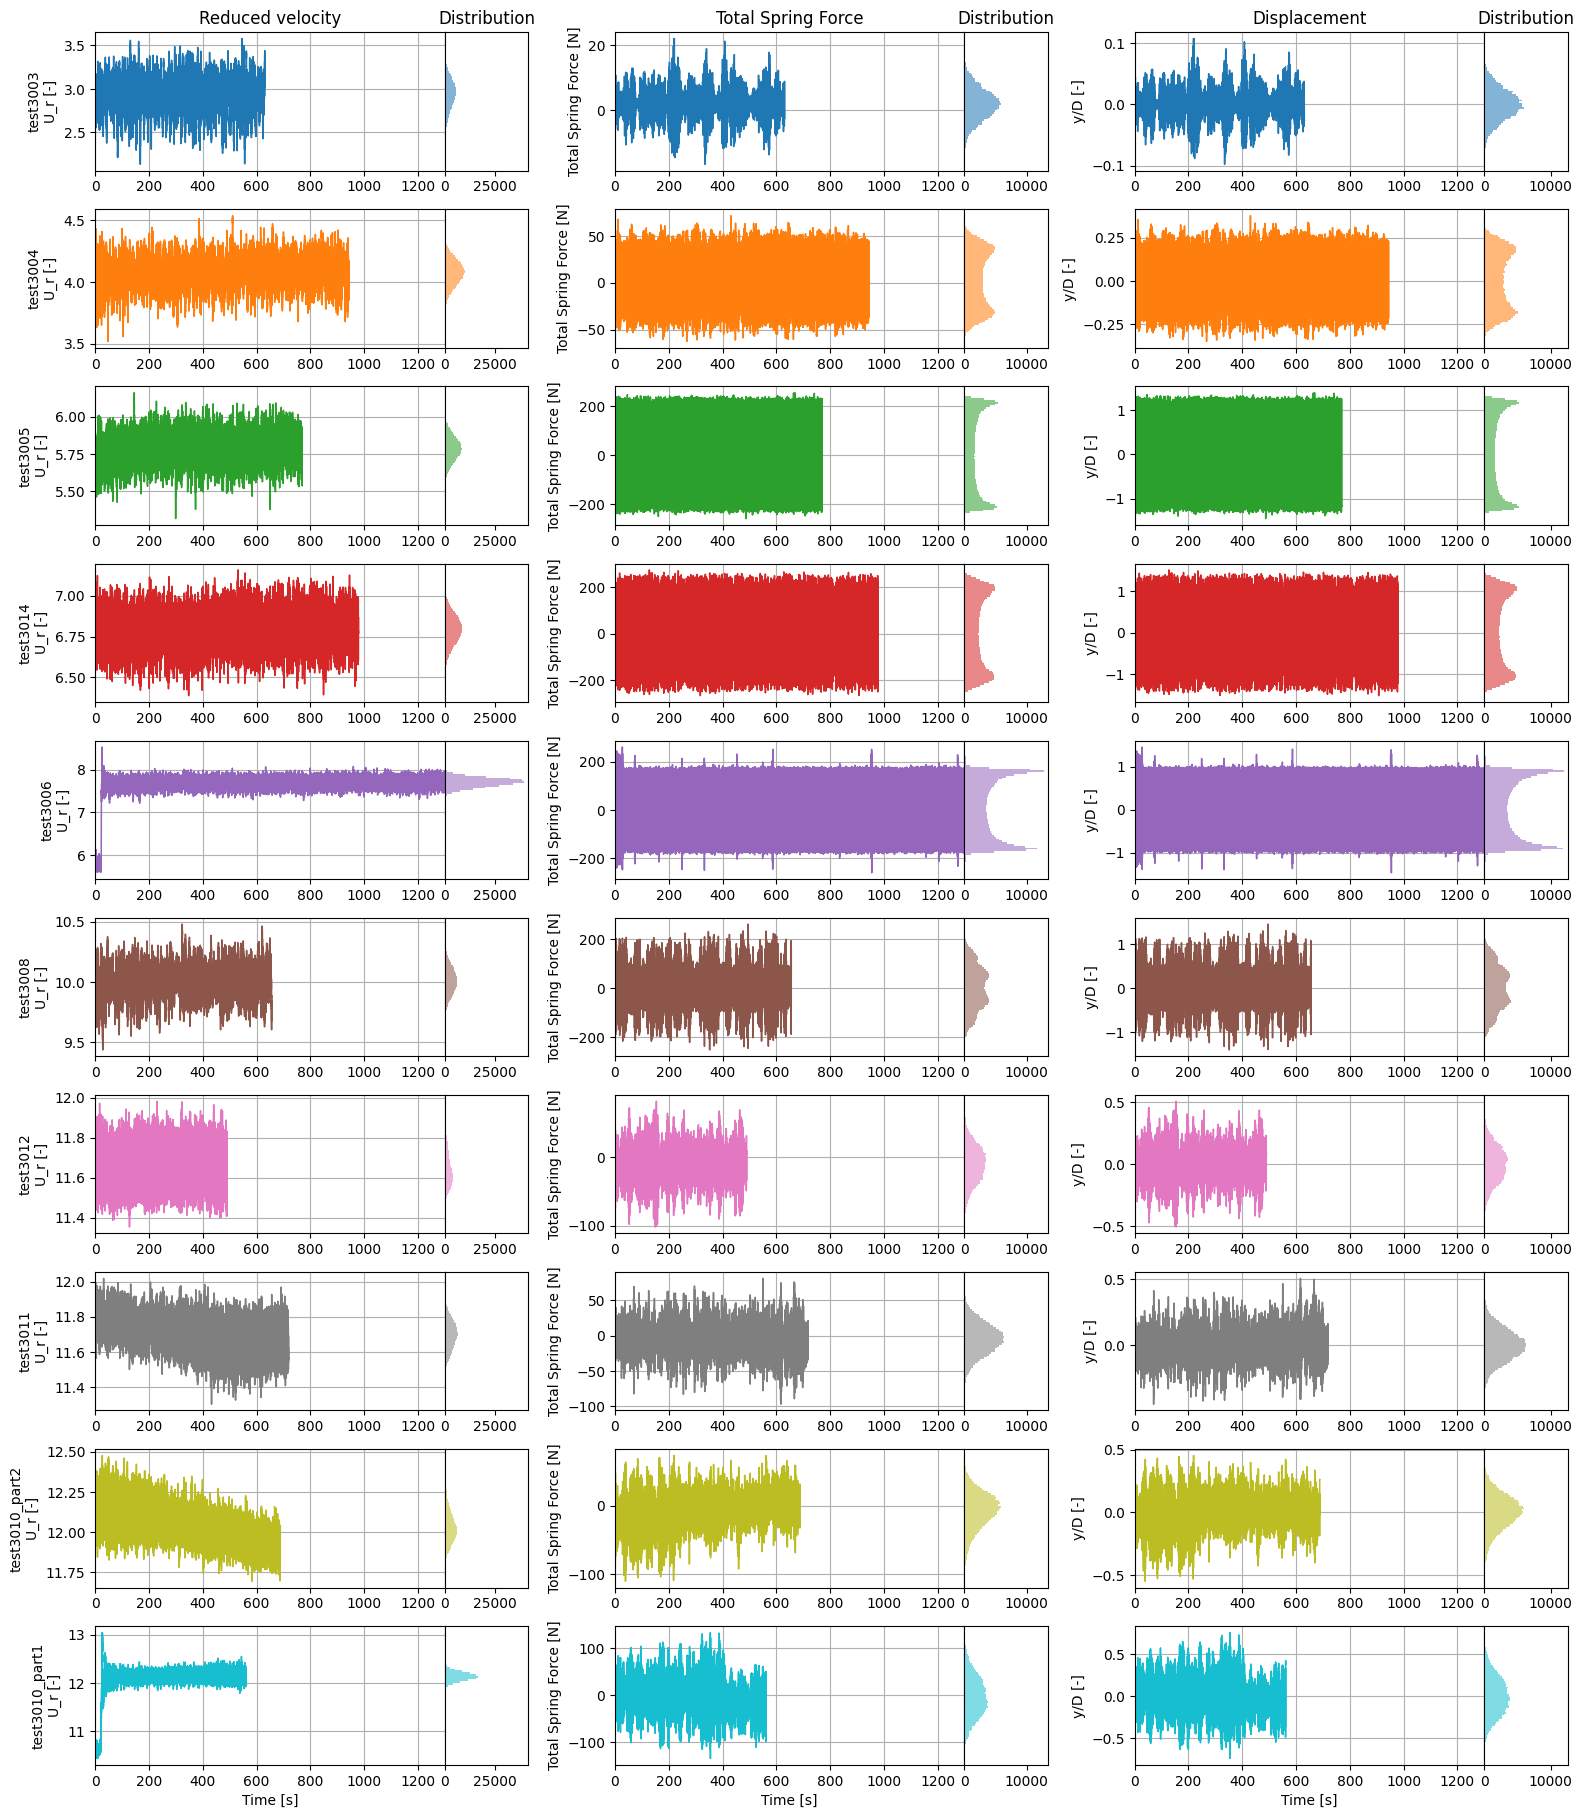

In [25]:
# Figure: U_r, raw Fy2-Fy1 from MAT, and displacement with right-side rotated histograms
TS_HIST_BINS = 70
TS_HIST_ALPHA = 0.55
TS_HIST_LINEWIDTH = 1.1
TS_HIST_FIG_W = 19
TS_HIST_ROW_H = 2.25
USE_NORMALIZED_DISPLACEMENT = True  # True -> y/D (mean removed), False -> raw displacement y (m)
SAVE_FIGURE_PNG = True
SAVE_FIGURE_PATH = Path('/Users/kasperslagstad/Desktop/Master-Thesis/Images/EDA/ExperimentalData/timeseries_raw.png')
SAVE_FIGURE_DPI = 300

# Layout control requested:
# - zero space inside each pair (timeseries <-> histogram)
# - large space between channel pairs
TS_PAIR_WSPACE = 0.00
TS_CHANNEL_GAP = 0.20
TS_ROW_GAP = 0.28

# Force requirement from user: use direct MAT channels only (no correction/scaling).
# Raw force = Fy2 - Fy1 = 9133_FORCE_4 - 9130_FORCE_1
_RAW_FORCE_CACHE = {}

def _mean_ur_for_sort(entry):
    ur = np.asarray(entry.get('ur_inst', []), dtype=float).reshape(-1)
    finite = ur[np.isfinite(ur)]
    if finite.size == 0:
        return float('inf')
    return float(np.mean(finite))

ordered_entries = sorted(entries, key=_mean_ur_for_sort)



def _raw_fy2_minus_fy1_series(entry):
    path = Path(entry['path']).resolve()
    key = str(path)
    if key in _RAW_FORCE_CACHE:
        return _RAW_FORCE_CACHE[key]

    data, channel_names = analysis._load_data_matrix(path, analysis.DATA_VARIABLE)

    # Use channel names when available; fallback to legacy column positions.
    fy1_fallback = 6 if data.shape[1] > 6 else max(0, data.shape[1] - 2)
    fy2_fallback = 9 if data.shape[1] > 9 else max(0, data.shape[1] - 1)

    time_raw = analysis._select_column(data, channel_names, ['time', 'Time'], 0, role='raw force time')
    fy1_raw = analysis._select_column(
        data,
        channel_names,
        ['9130_FORCE_1', 'Fy_spring1', 'fy_spring1'],
        fy1_fallback,
        role='raw Fy1',
    )
    fy2_raw = analysis._select_column(
        data,
        channel_names,
        ['9133_FORCE_4', 'Fy_spring2', 'fy_spring2'],
        fy2_fallback,
        role='raw Fy2',
    )

    time_arr = analysis._fill_nonfinite_1d(np.asarray(time_raw, dtype=float), role=f'{path.name}: time')
    fy1_arr = analysis._fill_nonfinite_1d(np.asarray(fy1_raw, dtype=float), role=f'{path.name}: Fy1')
    fy2_arr = analysis._fill_nonfinite_1d(np.asarray(fy2_raw, dtype=float), role=f'{path.name}: Fy2')

    n = int(min(time_arr.size, fy1_arr.size, fy2_arr.size))
    time_arr = np.asarray(time_arr[:n], dtype=float)
    force_raw = np.asarray(fy2_arr[:n] - fy1_arr[:n], dtype=float)

    trim_mask = analysis._time_trim_mask(
        time_arr,
        role=f'{path.name}: raw force trim',
        trim_start_seconds=float(getattr(analysis, 'TRIM_START_SECONDS', 0.0)),
        trim_end_seconds=float(getattr(analysis, 'TRIM_END_SECONDS', 0.0)),
    )
    time_arr = np.asarray(time_arr[trim_mask], dtype=float)
    force_raw = np.asarray(force_raw[trim_mask], dtype=float)

    if bool(getattr(analysis, 'USE_RELATIVE_TIME', True)) and time_arr.size > 0:
        time_plot = np.asarray(time_arr - float(time_arr[0]), dtype=float)
    else:
        time_plot = np.asarray(time_arr, dtype=float)

    _RAW_FORCE_CACHE[key] = (time_plot, force_raw)
    return _RAW_FORCE_CACHE[key]


n_rows = len(ordered_entries)
fig_ts = plt.figure(figsize=(TS_HIST_FIG_W, max(TS_HIST_ROW_H * n_rows, 2.8)))
outer = fig_ts.add_gridspec(
    n_rows,
    3,
    wspace=TS_CHANNEL_GAP,
    hspace=TS_ROW_GAP,
)

# axes_ts[row, col] where cols are:
# 0 line U_r, 1 hist U_r, 2 line force, 3 hist force, 4 line disp, 5 hist disp
axes_ts = np.empty((n_rows, 6), dtype=object)
line_refs = [None, None, None]
hist_refs = [None, None, None]

for i in range(n_rows):
    for g in range(3):
        sub = outer[i, g].subgridspec(1, 2, width_ratios=[4.8, 1.15], wspace=TS_PAIR_WSPACE)
        if line_refs[g] is None:
            ax_line = fig_ts.add_subplot(sub[0, 0])
            ax_hist = fig_ts.add_subplot(sub[0, 1])
            line_refs[g] = ax_line
            hist_refs[g] = ax_hist
        else:
            ax_line = fig_ts.add_subplot(sub[0, 0], sharex=line_refs[g])
            ax_hist = fig_ts.add_subplot(sub[0, 1], sharex=hist_refs[g])
        axes_ts[i, 2 * g] = ax_line
        axes_ts[i, 2 * g + 1] = ax_hist

# Titles on first row
axes_ts[0, 0].set_title('Reduced velocity')
axes_ts[0, 1].set_title('Distribution')
axes_ts[0, 2].set_title('Total Spring Force')
axes_ts[0, 3].set_title('Distribution')
axes_ts[0, 4].set_title('Displacement')
axes_ts[0, 5].set_title('Distribution')

for i, entry in enumerate(ordered_entries):
    color = colors[i % len(colors)]
    label = str(entry['label'])

    t_raw_force, fy_raw = _raw_fy2_minus_fy1_series(entry)
    ur = np.asarray(entry['ur_inst'], dtype=float)

    if USE_NORMALIZED_DISPLACEMENT:
        disp = np.asarray(entry['y_nd'], dtype=float)
        disp_ylabel = 'y/D (-)'
    else:
        disp = np.asarray(entry['y'], dtype=float)
        disp_ylabel = 'y (m)'

    n = int(min(t_raw_force.size, ur.size, fy_raw.size, disp.size))
    if n < 2:
        continue
    t = np.asarray(t_raw_force[:n], dtype=float)

    series = [
        (np.asarray(ur[:n], dtype=float), 'U_r [-]'),
        (np.asarray(fy_raw[:n], dtype=float), 'Total Spring Force [N]'),
        (np.asarray(disp[:n], dtype=float), "y/D [-]"),
    ]

    for k, (vals, ylab) in enumerate(series):
        ax_ts = axes_ts[i, 2 * k]
        ax_hist = axes_ts[i, 2 * k + 1]

        finite = np.isfinite(t) & np.isfinite(vals)
        t_plot = t[finite]
        v_plot = vals[finite]
        if t_plot.size == 0:
            continue

        ax_ts.plot(t_plot, v_plot, color=color, linewidth=TS_HIST_LINEWIDTH)
        ax_ts.margins(x=0)
        ax_ts.grid(True)
        if k == 0:
            ax_ts.set_ylabel(f"{label}\n{ylab}")
        else:
            ax_ts.set_ylabel(ylab)

        ax_hist.hist(
            v_plot,
            bins=int(TS_HIST_BINS),
            orientation='horizontal',
            color=color,
            alpha=TS_HIST_ALPHA,
            edgecolor='none',
        )
        ax_hist.set_ylim(ax_ts.get_ylim())
        ax_hist.grid(True, axis='y', alpha=0.35)
        ax_hist.set_xlabel('')
        ax_hist.set_yticks([])
        ax_hist.set_yticklabels([])
        ax_hist.tick_params(axis='y', left=False)
        ax_hist.spines['left'].set_visible(True)

for j in [0, 2, 4]:
    axes_ts[-1, j].set_xlabel('Time [s]')
for j in [1, 3, 5]:
    axes_ts[-1, j].set_xlabel('')

fig_ts.tight_layout()
if bool(SAVE_FIGURE_PNG):
    save_path = Path(SAVE_FIGURE_PATH)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig_ts.savefig(save_path, dpi=int(SAVE_FIGURE_DPI), bbox_inches='tight')
    print(f'Saved figure to {save_path.resolve()}')
plt.show()
